# Assignment 3

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model](https://open.spotify.com/track/4R3AU2pjv8ge2siX1fVbZs?si=b2712f32da0e4358) or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [1]:
# Load the libraries as required.
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge  # Baseline regressor
from sklearn.ensemble import RandomForestRegressor  # Advanced regressor
from sklearn.model_selection import GridSearchCV, cross_val_score

In [2]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [3]:
X = fires_dt.drop(columns='area')
Y = fires_dt['area']
print(X.head())
print(Y.head())
print(X.isnull().sum())  # Check for missing values
print(Y.isnull().sum())

   coord_x  coord_y month  day  ffmc   dmc     dc  isi  temp  rh  wind  rain
0        7        5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0
1        7        4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0
2        7        4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0
3        8        6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2
4        8        6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: area, dtype: float64
coord_x    0
coord_y    0
month      0
day        0
ffmc       0
dmc        0
dc         0
isi        0
temp       0
rh         0
wind       0
rain       0
dtype: int64
0


In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define numeric and categorical features
numeric_features = ['coord_x', 'coord_y', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain']
categorical_features = ['month', 'day']

# Explicitly specify categories for month and day to prevent errors
month_categories = [
    'jan', 'feb', 'mar', 'apr', 'may', 'jun',
    'jul', 'aug', 'sep', 'oct', 'nov', 'dec'
]
day_categories = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']

# Define the OneHotEncoder with explicit categories
categorical_transformer = OneHotEncoder(categories=[month_categories, day_categories])

# Create Preproc1: Numeric scaler only
preproc1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [24]:
from sklearn.preprocessing import FunctionTransformer

# Apply a non-linear transformation, e.g., log(1 + x) to handle skewed data
non_linear_transformer = FunctionTransformer(np.log1p, validate=True)

# Create Preproc2: Numeric scaler with non-linear transformation
preproc2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('non_linear', non_linear_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [25]:
# Pipeline A = preproc1 + baseline
# Baseline regressor: Ridge Regression
baseline_model = Ridge()

# Advanced regressor: Random Forest
advanced_model = RandomForestRegressor()

# Pipeline A: preproc1 + baseline model
pipeline_A = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', baseline_model)
])

In [26]:
# Pipeline B = preproc2 + baseline
pipeline_B = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', baseline_model)
])


In [27]:
# Pipeline C = preproc1 + advanced model
pipeline_C = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', advanced_model)
])


In [28]:
# Pipeline D = preproc2 + advanced model

pipeline_D = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', advanced_model)
])


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [29]:
param_grid_A = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0]  # Tuning the alpha parameter for Ridge Regression
}

In [30]:
param_grid_B = {
    'regressor__alpha': [0.01, 0.1, 1.0, 10.0]  # Same parameter tuning for Ridge Regression
}



In [31]:
param_grid_C = {
    'regressor__n_estimators': [50, 100, 150, 200],  # Number of trees in Random Forest
    'regressor__max_depth': [None, 10, 20, 30]       # Maximum depth of trees
}


In [32]:
param_grid_D = {
    'regressor__n_estimators': [50, 100, 150, 200],  # Same number of trees for Random Forest
    'regressor__max_depth': [None, 10, 20, 30]       # Same depth tuning
}


In [33]:
from sklearn.model_selection import GridSearchCV

# Perform GridSearch for Pipeline A
grid_search_A = GridSearchCV(pipeline_A, param_grid_A, cv=5, scoring='neg_mean_squared_error')
grid_search_A.fit(X, Y)

# Perform GridSearch for Pipeline B
grid_search_B = GridSearchCV(pipeline_B, param_grid_B, cv=5, scoring='neg_mean_squared_error')
grid_search_B.fit(X, Y)

# Perform GridSearch for Pipeline C
grid_search_C = GridSearchCV(pipeline_C, param_grid_C, cv=5, scoring='neg_mean_squared_error')
grid_search_C.fit(X, Y)

# Perform GridSearch for Pipeline D
grid_search_D = GridSearchCV(pipeline_D, param_grid_D, cv=5, scoring='neg_mean_squared_error')
grid_search_D.fit(X, Y)



# Get the best model and performance metrics for each pipeline
best_model_pipeline1 = grid_search_A.best_estimator_
best_score_pipeline1 = -grid_search_A.best_score_  # Negate to get positive MAE

best_model_pipeline2 = grid_search_B.best_estimator_
best_score_pipeline2 = -grid_search_B.best_score_

best_model_pipeline3 = grid_search_C.best_estimator_
best_score_pipeline3 = -grid_search_C.best_score_

best_model_pipeline4 = grid_search_D.best_estimator_
best_score_pipeline4 = -grid_search_D.best_score_

# Output the results
print(f"Best model for Pipeline 1: {best_model_pipeline1} with MAE: {best_score_pipeline1}")
print(f"Best model for Pipeline 2: {best_model_pipeline2} with MAE: {best_score_pipeline2}")
print(f"Best model for Pipeline 3: {best_model_pipeline3} with MAE: {best_score_pipeline3}")
print(f"Best model for Pipeline 4: {best_model_pipeline4} with MAE: {best_score_pipeline4}")

# Compare performance across all pipelines
scores = {
    'Pipeline 1': best_score_pipeline1,
    'Pipeline 2': best_score_pipeline2,
    'Pipeline 3': best_score_pipeline3,
    'Pipeline 4': best_score_pipeline4,
}

# Identify the best pipeline
best_pipeline = min(scores, key=scores.get)  # Minimize MAE
best_performance = scores[best_pipeline]

print(f"The best performing model is {best_pipeline} with MAE: {best_performance}")

Best model for Pipeline 1: Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['coord_x', 'coord_y', 'ffmc',
                                                   'dmc', 'dc', 'isi', 'temp',
                                                   'rh', 'wind', 'rain']),
                                                 ('cat',
                                                  OneHotEncoder(categories=[['jan',
                                                                             'feb',
                                                                             'mar',
                                                                             'apr',
                                                                             'may',
                                                                             'jun',
                                                                    

# Evaluate

+ Which model has the best performance?
pipeline_A random forest 
The best performing model is Pipeline 1 with MAE: 4278.655355069461


# Export

+ Save the best performing model to a pickle file.

In [34]:

# Assuming 'best_model' is the best-performing model obtained from the grid search
best_model = grid_search_A.best_estimator_  # Adjust this based on your actual best pipeline


import pickle

# Save the best model to a pickle file
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

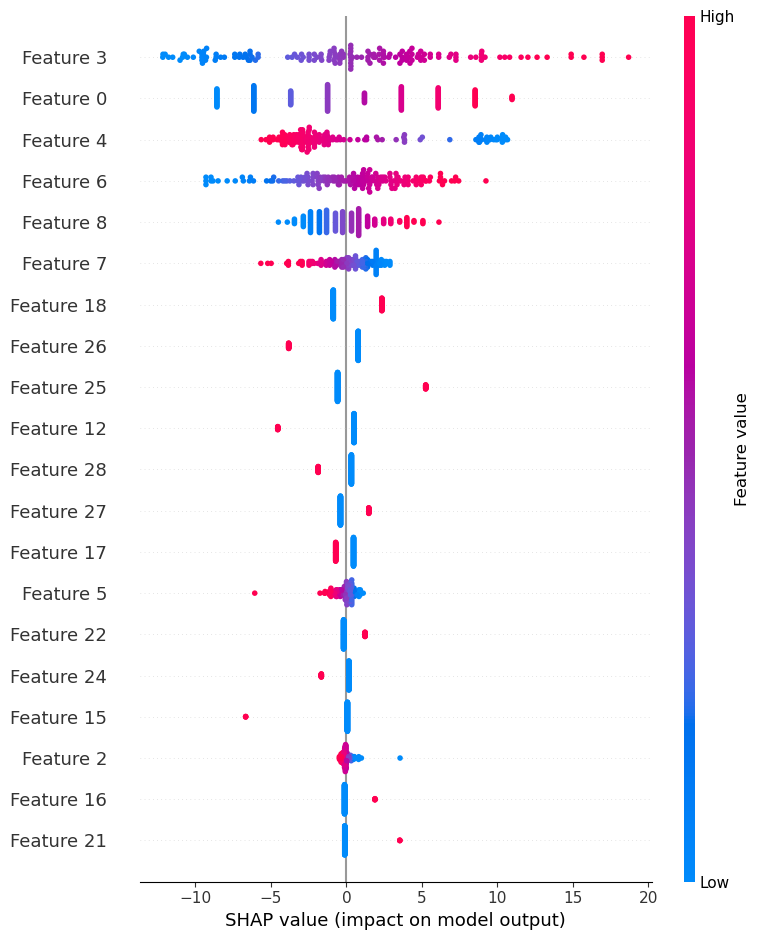

In [ ]:


import shap 


# After fitting your grid search and selecting the best model
best_model_pipeline = grid_search_A.best_estimator_  # Or whichever grid search you used

# Fit the best model pipeline on your training data
best_model_pipeline.fit(X_train, Y_train)  # Make sure to have X_train and Y_train defined

# Now you can use the best model pipeline to transform your test set
X_test_transformed = best_model_pipeline.named_steps['preprocessing'].transform(X_test)

# Create SHAP explainer using the fitted model
explainer = shap.Explainer(best_model_pipeline.named_steps['regressor'], X_test_transformed)

# Compute SHAP values for the entire test set
shap_values = explainer(X_test_transformed)

# Proceed with selecting an observation
observation_index = 0  # Change as needed
shap_values_observation = explainer(X_test_transformed[observation_index:observation_index + 1])

# Step 1: Assuming you have already computed shap_values for the entire test set

# Step 2: Select a specific observation to explain
observation_index = 0  # Change to the index of the observation you want to explain
shap_values_observation = explainer(X_test_transformed[observation_index:observation_index + 1])

# Step 3: Force plot for the specific observation
shap.initjs()  # Necessary for rendering in Jupyter Notebooks
shap.force_plot(explainer.expected_value, shap_values_observation.values, X_test_transformed[observation_index])

# Step 4: Summary plot for global feature importance
shap.summary_plot(shap_values, X_test_transformed)

*(Answer here.)*
feature 3 is the most important and feature 21 is the least important 
Remove Feature 21: Since you noted that feature 21 is the lowest in the SHAP summary plot, it indicates that this feature has minimal impact on the predictions. This makes it a strong candidate for removal.
Additional Candidates: If there are other features that are also low on the plot (e.g., those with SHAP values close to zero or that do not consistently push predictions higher or lower), consider them as well.
Rationale for Removal:

Noise Reduction: Features that contribute minimally can introduce noise to the model, complicating the training process without providing significant predictive power.
Model Simplification: Reducing the number of features can enhance interpretability and decrease overfitting, especially in smaller datasets.
2. Test the Impact of Removing Features
To determine whether removing certain features enhances or degrades model performance, follow these steps:

A. Create Baseline Model:

Train your original model using all features and record its performance metrics (e.g., MAE, RMSE, R²) on the validation/test set.
B. Create a Reduced Model:

Create a new model excluding feature 21 (and any other features you deem appropriate). Train this model using the same training data.
C. Evaluate Performance:

Evaluate the performance of the reduced model on the validation/test set using the same metrics as before.
D. Compare Performance:

Compare the performance of the baseline model with the reduced model:
If the reduced model performs similarly or better, it indicates that the removed features were not enhancing model performance and can be excluded.
If the reduced model performs worse, it suggests that those features did provide valuable information and should be retained.
3. Statistical Tests (Optional)
If you want to be more rigorous in testing the impact of removing features, consider conducting statistical tests such as:

Cross-Validation: Use k-fold cross-validation to assess the performance of both models across multiple splits of the data.
Feature Importance Analysis: Use methods like permutation importance to further assess the contribution of features after fitting the model.



## Criteria

The [rubric](./assignment_3_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-3`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_3.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.